# Preprocessing & Feature Engineering — Fraud Detection Capstone
**Goal:** Transform raw transaction data into a clean, model-ready dataset.  
**Output:** `data/processed/train_preprocessed.csv` and `data/processed/test_preprocessed.csv`

## 1. Setup

In [1]:
import os
os.chdir('..')
print(os.getcwd())

/Users/cds.chintan/IIT PG DS & AI/Sem 3/AIML Project/fraud-detection-capstone


In [6]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

train = pd.read_csv('data/raw/fraudTrain.csv', index_col=0)
test  = pd.read_csv('data/raw/fraudTest.csv',  index_col=0)

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Columns: {train.columns.tolist()}')

Train: (1296675, 22) | Test: (555719, 22)
Columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


## 2. Drop Irrelevant & PII Columns
These columns are either identifiers, free-text, or direct leakage risks.

In [7]:
DROP_COLS = [
    'cc_num',     # card number — identifier, not a pattern
    'first',      # PII
    'last',       # PII
    'street',     # too granular, city/state/zip covers location
    'trans_num',  # transaction ID — unique per row, no signal
    'unix_time',  # redundant with trans_date_trans_time
]

train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)

print(f'After drop — Train: {train.shape} | Test: {test.shape}')
print(f'Remaining columns: {train.columns.tolist()}')

After drop — Train: (1296675, 16) | Test: (555719, 16)
Remaining columns: ['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat', 'merch_long', 'is_fraud']


## 3. DateTime Feature Engineering
Extract meaningful temporal signals from the transaction timestamp.

In [9]:
def extract_datetime_features(df):
    df = df.copy()
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    
    df['hour']          = df['trans_date_trans_time'].dt.hour
    df['day_of_week']   = df['trans_date_trans_time'].dt.dayofweek   # 0=Mon, 6=Sun
    df['month']         = df['trans_date_trans_time'].dt.month
    df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
    df['is_night']      = ((df['hour'] >= 22) | (df['hour'] <= 3)).astype(int)
    
    # df = df.drop(columns=['trans_date_trans_time'])
    return df

train = extract_datetime_features(train)
test  = extract_datetime_features(test)

print('New datetime features: hour, day_of_week, month, is_weekend, is_night')
print(train[['hour','day_of_week','month','is_weekend','is_night']].head())

New datetime features: hour, day_of_week, month, is_weekend, is_night
   hour  day_of_week  month  is_weekend  is_night
0     0            1      1           0         1
1     0            1      1           0         1
2     0            1      1           0         1
3     0            1      1           0         1
4     0            1      1           0         1


## 4. Age Feature from Date of Birth

In [11]:
def extract_age(df, ref_date='2020-06-21'):
    """
    We use a fixed reference date to avoid data leakage.
    Using transaction time per row would be correct too,
    but a fixed date is simpler and negligible difference.
    """
    df = df.copy()
    df['dob'] = pd.to_datetime(df['dob'])
    ref = pd.Timestamp(ref_date)
    df['age'] = (ref - df['dob']).dt.days // 365
    # df = df.drop(columns=['dob'])
    return df

train = extract_age(train)
test  = extract_age(test)

print('Age feature created.')
print(f'Age range: {train["age"].min()} — {train["age"].max()} years')
print(train['age'].describe().round(2))

Age feature created.
Age range: 15 — 95 years
count    1296675.00
mean          46.25
std           17.41
min           15.00
25%           33.00
50%           44.00
75%           57.00
max           95.00
Name: age, dtype: float64


## 5. Geographic Distance Feature
Haversine distance between cardholder home and merchant location.  
This was one of the strongest signals identified in EDA.

In [12]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

train['geo_distance'] = haversine(train['lat'], train['long'],
                                   train['merch_lat'], train['merch_long'])
test['geo_distance']  = haversine(test['lat'],  test['long'],
                                   test['merch_lat'],  test['merch_long'])

# Drop raw coordinates — geo_distance captures the signal
train = train.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'])
test  = test.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'])

print('Geo distance feature created. Raw coordinates dropped.')
print(f'Median geo distance (fraud) : {train[train.is_fraud==1]["geo_distance"].median():.2f} km')
print(f'Median geo distance (legit) : {train[train.is_fraud==0]["geo_distance"].median():.2f} km')

Geo distance feature created. Raw coordinates dropped.
Median geo distance (fraud) : 77.93 km
Median geo distance (legit) : 78.23 km


## 6. Encode Categorical Features
Using frequency encoding for high-cardinality columns and label encoding for low-cardinality ones.

In [13]:
# --- Label encode low-cardinality columns ---
LABEL_COLS = ['gender']
for col in LABEL_COLS:
    train[col] = train[col].astype('category').cat.codes
    test[col]  = test[col].astype('category').cat.codes

# --- Frequency encode high-cardinality columns ---
# Fit frequency map on TRAIN only to avoid leakage
FREQ_COLS = ['merchant', 'category', 'city', 'state', 'job']

freq_maps = {}
for col in FREQ_COLS:
    freq_map = train[col].value_counts(normalize=True).to_dict()
    freq_maps[col] = freq_map
    train[col] = train[col].map(freq_map)
    test[col]  = test[col].map(freq_map).fillna(0)  # unseen values → 0

print('Encoding complete.')
print(f'Label encoded  : {LABEL_COLS}')
print(f'Freq encoded   : {FREQ_COLS}')
train.head(3)

Encoding complete.
Label encoded  : ['gender']
Freq encoded   : ['merchant', 'category', 'city', 'state', 'job']


,trans_date_trans_time,merchant,category,amt,gender,city,state,zip,city_pop,job,dob,is_fraud,hour,day_of_week,month,is_weekend,is_night,age,geo_distance
0,2019-01-01 00:00:18,0.000977,0.048807,4.97,0,0.001564,0.023341,28654,3495,0.002734,1988-03-09,0,0,1,1,0,1,32,78.597568
1,2019-01-01 00:00:44,0.001930,0.095350,107.23,0,0.002734,0.014594,99160,149,0.003932,1978-06-21,0,0,1,1,0,1,42,30.212176
2,2019-01-01 00:00:51,0.001461,0.072504,220.11,1,0.000388,0.004276,83252,4154,0.000394,1962-01-19,0,0,1,1,0,1,58,108.206083


## 7. Final Feature Set Verification

In [14]:
TARGET = 'is_fraud'
FEATURES = [c for c in train.columns if c != TARGET]

print(f'Total features : {len(FEATURES)}')
print(f'Target         : {TARGET}')
print(f'\nFeature list:')
for f in FEATURES:
    print(f'  {f:<20} dtype: {train[f].dtype}')

print(f'\nMissing values in train: {train.isnull().sum().sum()}')
print(f'Missing values in test : {test.isnull().sum().sum()}')

Total features : 18
Target         : is_fraud

Feature list:
  trans_date_trans_time dtype: datetime64[ns]
  merchant             dtype: float64
  category             dtype: float64
  amt                  dtype: float64
  gender               dtype: int8
  city                 dtype: float64
  state                dtype: float64
  zip                  dtype: int64
  city_pop             dtype: int64
  job                  dtype: float64
  dob                  dtype: datetime64[ns]
  hour                 dtype: int32
  day_of_week          dtype: int32
  month                dtype: int32
  is_weekend           dtype: int64
  is_night             dtype: int64
  age                  dtype: int64
  geo_distance         dtype: float64

Missing values in train: 0
Missing values in test : 0


## 8. Feature Distributions After Preprocessing

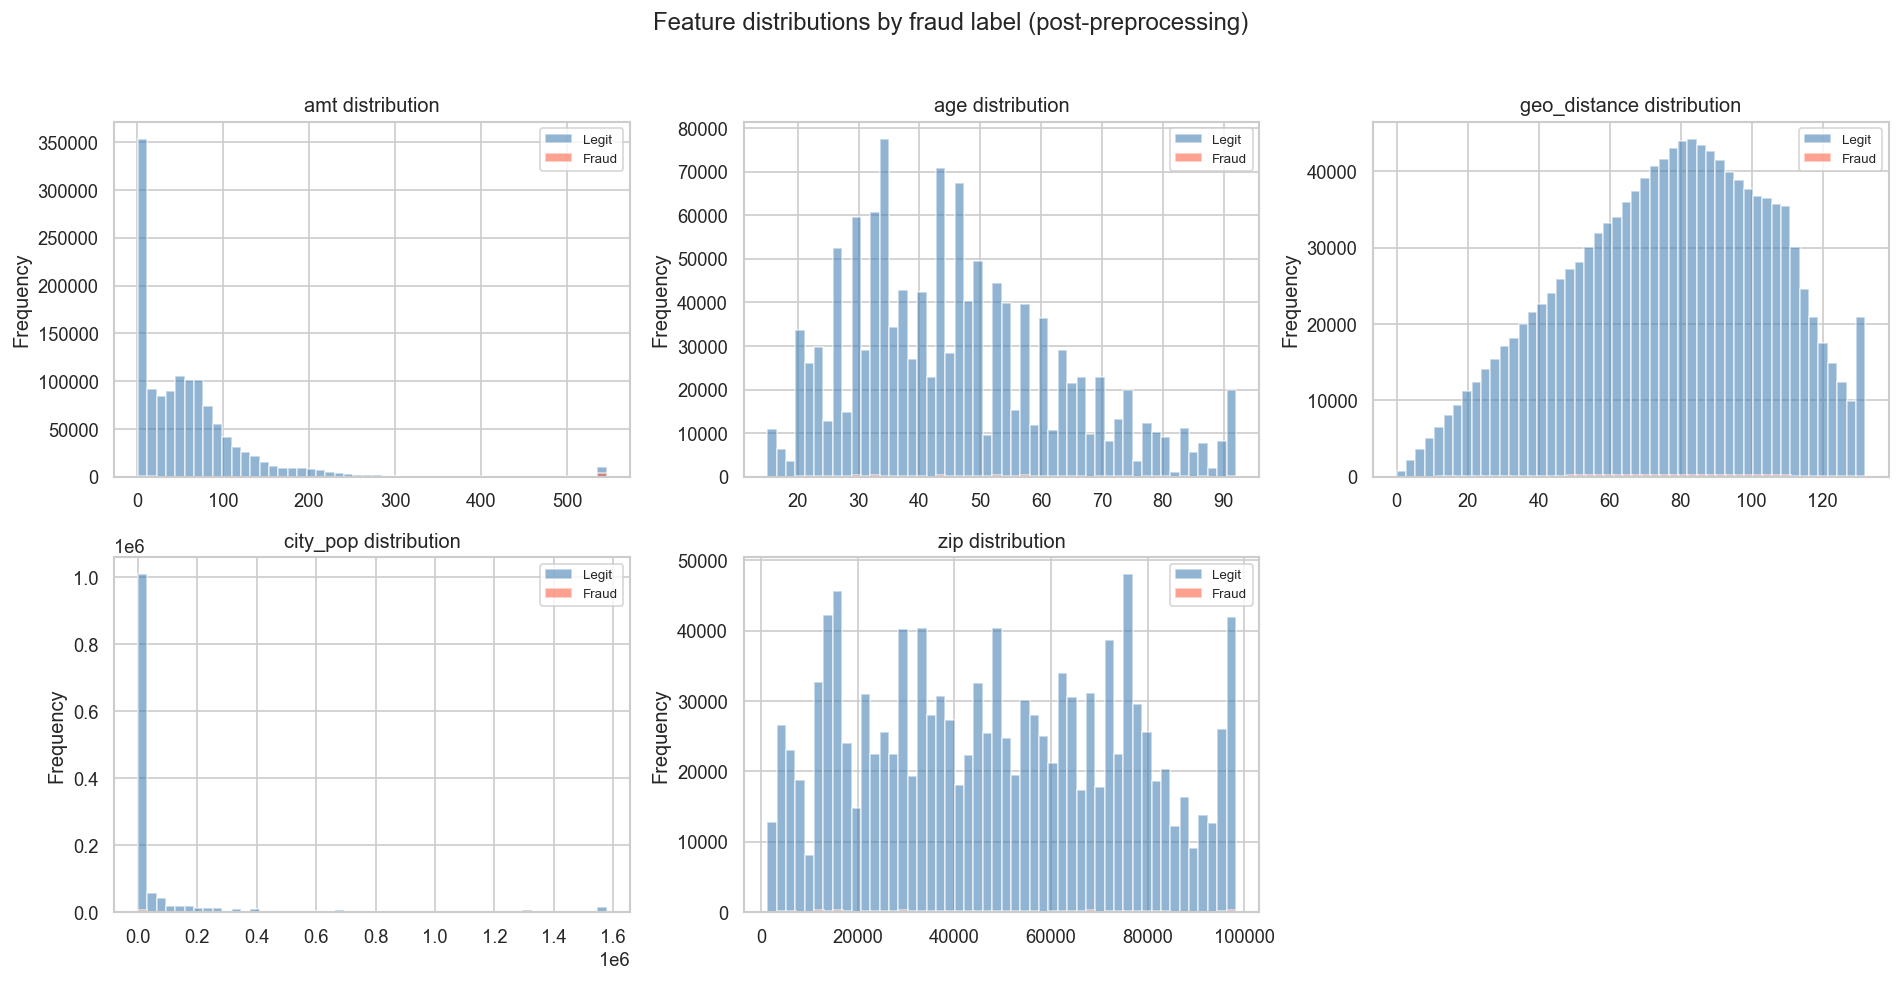

In [15]:
num_features = ['amt', 'age', 'geo_distance', 'city_pop', 'zip']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    train[train[TARGET]==0][col].clip(
        upper=train[col].quantile(0.99)).plot(
        kind='hist', bins=50, alpha=0.6,
        color='steelblue', label='Legit', ax=axes[i])
    train[train[TARGET]==1][col].clip(
        upper=train[col].quantile(0.99)).plot(
        kind='hist', bins=50, alpha=0.6,
        color='tomato', label='Fraud', ax=axes[i])
    axes[i].set_title(f'{col} distribution')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature distributions by fraud label (post-preprocessing)', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/feature_distributions.png', bbox_inches='tight')
plt.show()

## 9. Save Processed Data

In [16]:
os.makedirs('data/processed', exist_ok=True)

train.to_csv('data/processed/train_preprocessed.csv', index=False)
test.to_csv('data/processed/test_preprocessed.csv',   index=False)

print('Saved successfully.')
print(f'Train processed : data/processed/train_preprocessed.csv — {train.shape}')
print(f'Test processed  : data/processed/test_preprocessed.csv  — {test.shape}')
print(f'\nFraud rate (train): {train[TARGET].mean():.4%}')
print(f'Fraud rate (test) : {test[TARGET].mean():.4%}')

Saved successfully.
Train processed : data/processed/train_preprocessed.csv — (1296675, 19)
Test processed  : data/processed/test_preprocessed.csv  — (555719, 19)

Fraud rate (train): 0.5789%
Fraud rate (test) : 0.3860%


## 10. Preprocessing Summary

In [17]:
print('=' * 50)
print('     PREPROCESSING SUMMARY')
print('=' * 50)
print(f'Original features      : 23')
print(f'Features after prep    : {len(FEATURES)}')
print(f'\nDropped (PII/ID)       : cc_num, first, last, street, trans_num, unix_time')
print(f'New features created   : hour, day_of_week, month, is_weekend, is_night, age, geo_distance')
print(f'Encoded (label)        : gender')
print(f'Encoded (frequency)    : merchant, category, city, state, job')
print(f'\nTrain shape            : {train.shape}')
print(f'Test shape             : {test.shape}')
print(f'Missing values         : 0')
print('=' * 50)
print('Ready for model training.')

     PREPROCESSING SUMMARY
Original features      : 23
Features after prep    : 18

Dropped (PII/ID)       : cc_num, first, last, street, trans_num, unix_time
New features created   : hour, day_of_week, month, is_weekend, is_night, age, geo_distance
Encoded (label)        : gender
Encoded (frequency)    : merchant, category, city, state, job

Train shape            : (1296675, 19)
Test shape             : (555719, 19)
Missing values         : 0
Ready for model training.
